### DBSCAN from scratch

In [36]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors

sns.set_theme()

### Create Dataset

<Axes: xlabel='dim1', ylabel='dim2'>

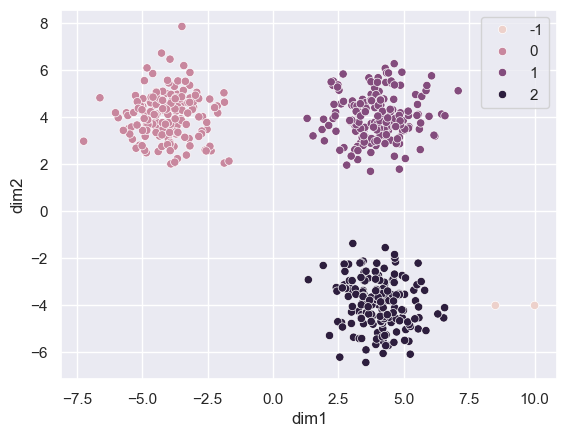

In [37]:
# create a make blob data
X, y = make_blobs(n_samples=500, n_features=2, random_state=42, centers=[[-4,4],[4,4], [4,-4]])

# add noise in the data
X = np.vstack((X,np.array([[8.5,-4],[10,-4]])))
y = np.concatenate((y,np.array([-1,-1])))

# convert to dataframe
X_df = pd.DataFrame(X, columns=['dim1', 'dim2'])

sns.scatterplot(X_df,x='dim1',y='dim2', hue=y)

#### Radius neighbors

In [38]:
nearest_neigh = NearestNeighbors()
nearest_neigh = nearest_neigh.fit(X)

In [39]:
example_data_point_id = 0
np.expand_dims(X[example_data_point_id], axis=0)

array([[ 3.47727698, -2.95099077]])

In [40]:
nearest_neigh.radius_neighbors(np.expand_dims(X[example_data_point_id],axis=0),
                               radius=0.2,
                               return_distance=True)

(array([array([0.18096934, 0.03363485, 0.        , 0.19579558])],
       dtype=object),
 array([array([305, 170,   0, 114], dtype=int64)], dtype=object))

In [41]:
set(nearest_neigh.radius_neighbors(X[[0,1],:],
                               radius=0.2,
                               return_distance=False)[0])

{0, 114, 170, 305}

#### DBSCAN

In [42]:
# set main parameter
eps = 1
min_sample = 5

In [43]:
# create dataframe to store results
points_df = pd.DataFrame(index=X_df.index)

points_df['cluster'] = None
points_df['core'] = False
points_df['unvisited'] = True
points_df['border'] = False

points_df.head()

,cluster,core,unvisited,border
0,None,False,True,False
1,None,False,True,False
2,None,False,True,False
3,None,False,True,False
4,None,False,True,False


In [44]:
# id for the first cluster
current_cluster = 0

# outer loop to iterate all the points
while True:

    # if all points are visited come out of loop
    if points_df['unvisited'].sum() == 0:
        break

    # get the first unvisted point 
    curr_point = points_df[points_df['unvisited']].index[0]

    # Get the nearest neighbors for the current unvisited point
    cluster_points = set(nearest_neigh.radius_neighbors(
        np.expand_dims(X[curr_point],axis=0),
        radius=eps,
        return_distance=False
    )[0]
    )

    # Check if the current point is qualified for the core point,
    # start building cluster
    if len(cluster_points) >= min_sample:

        # add the cluster id in the cluster
        points_df.loc[curr_point, 'cluster'] = current_cluster
        points_df.loc[curr_point, 'core'] = True

        # get all the neighbours which are unvisited and create a list
        cluster_points = {point for point in cluster_points if points_df.loc[point,'unvisited']}

        # iterate through neighbors and build the cluster
        while True:
            # pop the current neighbour
            curr_neighbor_point = cluster_points.pop()

            # add it to visited
            points_df.loc[curr_neighbor_point,'unvisited'] = False
            points_df.loc[curr_neighbor_point,'cluster'] = current_cluster

            # get the neighbors around this point
            neighbour_points = set(nearest_neigh.radius_neighbors(
                np.expand_dims(X[curr_neighbor_point], axis=0),
                radius=eps,
                return_distance=False
            )[0]
            )

            # check if this point is core point or border point
            if len(neighbour_points) >= min_sample:
                # mark this point as core point
                points_df.loc[curr_neighbor_point,'core'] = True
                # add the neighbors of the current point into the current neighbor
                add_points = {point for point in neighbour_points if points_df.loc[point, 'unvisited']}
                cluster_points.update(add_points)
            else:
                # add this as a border point
                points_df.loc[curr_neighbor_point,'border'] = True
        
            # if neightbors point are visited then we'll break out of the loop
            if len(cluster_points) == 0:
                break
    else:
        # current point is not core point
        # mark it as visited point
        points_df.loc[curr_point,'unvisited'] = False
    
    # update the cluster id
    current_cluster += 1

In [45]:
# find all the points without cluster id
remaining_points = points_df[points_df['cluster'].isna()].index.tolist()
core_points = points_df[points_df['core']==True].index.tolist()

# iterate through all the remaining points
for point in remaining_points:

    # find the neighbor which is at eps distance from the current point
    cluster_neighbor = nearest_neigh.radius_neighbors(
        np.expand_dims(X[point], axis=0),
        radius=eps,
        return_distance=False
    )[0]

    if cluster_neighbor.shape[0] == 1:
        # assign the cluster to -1
        points_df.loc[point, 'cluster'] = -1
    
    else:
        for neighbor in cluster_neighbor:
            if neighbor in core_points:
                points_df.loc[point, 'cluster'] = points_df.loc[neighbor, 'cluster']
                points_df.loc[point, 'border'] = True
        if points_df.loc[point, 'cluster'] is None:
            points_df.loc[point, 'cluster'] = -1

<Axes: xlabel='dim1', ylabel='dim2'>

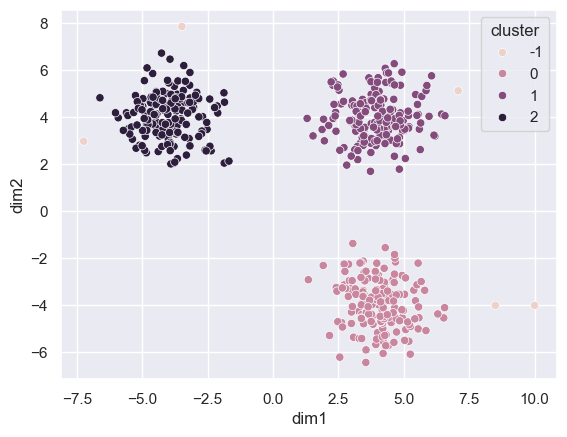

In [46]:
#plot the value after DBSCAN algo
sns.scatterplot(X_df, x='dim1', y='dim2', hue=points_df['cluster'])